In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sriramr/fruits-fresh-and-rotten-for-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification


In [2]:
import os

print(os.listdir(path))

['dataset']


In [3]:
for root, dirs, files in os.walk(path):
    print(root)
    print("Folders:", dirs[:10])
    print("Files:", files[:5])
    print("-"*70)

    if root.count(os.sep) > path.count(os.sep) + 2:
        break

/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification
Folders: ['dataset']
Files: []
----------------------------------------------------------------------
/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset
Folders: ['dataset', 'test', 'train']
Files: []
----------------------------------------------------------------------
/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset
Folders: ['test', 'train']
Files: []
----------------------------------------------------------------------
/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test
Folders: ['rottenbanana', 'freshoranges', 'rottenoranges', 'freshbanana', 'rottenapples', 'freshapples']
Files: []
----------------------------------------------------------------------


In [4]:
import os
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

warnings.filterwarnings("ignore")

print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.20.0


In [5]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [6]:
DATASET_PATH = "/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
TEST_DIR = os.path.join(DATASET_PATH, "test")

print(TRAIN_DIR)
print(TEST_DIR)

/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/train
/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test


In [7]:
classes = sorted(os.listdir(TRAIN_DIR))

print("Classes Found:\n")

for cls in classes:
    print(cls)

Classes Found:

freshapples
freshbanana
freshoranges
rottenapples
rottenbanana
rottenoranges


In [8]:
image_count = {}

for cls in classes:

    folder = os.path.join(TRAIN_DIR, cls)

    image_count[cls] = len(os.listdir(folder))

for cls, count in image_count.items():
    print(f"{cls:<20} {count}")

freshapples          1693
freshbanana          1581
freshoranges         1466
rottenapples         2342
rottenbanana         2224
rottenoranges        1595


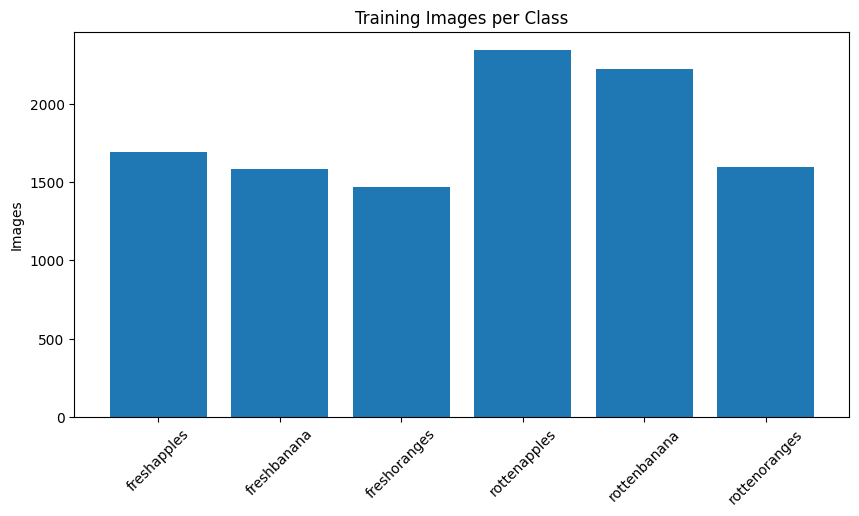

In [9]:
plt.figure(figsize=(10,5))

plt.bar(
    image_count.keys(),
    image_count.values()
)

plt.xticks(rotation=45)

plt.ylabel("Images")

plt.title("Training Images per Class")

plt.show()

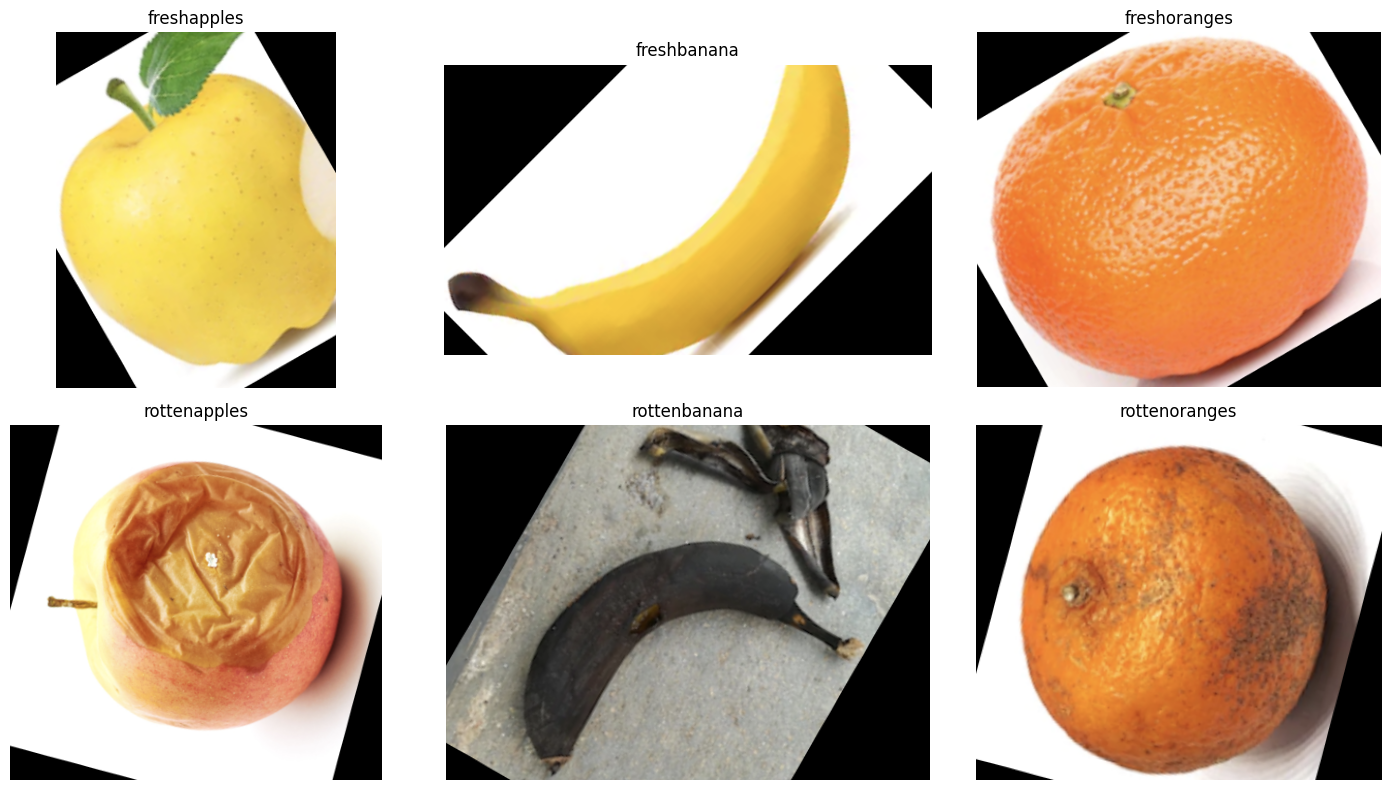

In [10]:
plt.figure(figsize=(15,8))

for i, cls in enumerate(classes):

    folder = os.path.join(TRAIN_DIR, cls)

    image_name = random.choice(os.listdir(folder))

    image_path = os.path.join(folder, image_name)

    img = plt.imread(image_path)

    plt.subplot(2,3,i+1)

    plt.imshow(img)

    plt.title(cls)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [11]:
IMAGE_SIZE = (224,224)

BATCH_SIZE = 32

AUTOTUNE = tf.data.AUTOTUNE

In [12]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

Found 10901 files belonging to 6 classes.


2026-07-21 01:53:40.652213: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [13]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 2698 files belonging to 6 classes.


In [14]:
class_names = train_ds.class_names

print(class_names)

['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']


In [15]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.10),

    layers.RandomZoom(0.10),

    layers.RandomContrast(0.10)

])

In [16]:
train_ds = (
    train_ds
    .cache()
    .shuffle(1000)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .cache()
    .prefetch(AUTOTUNE)
)

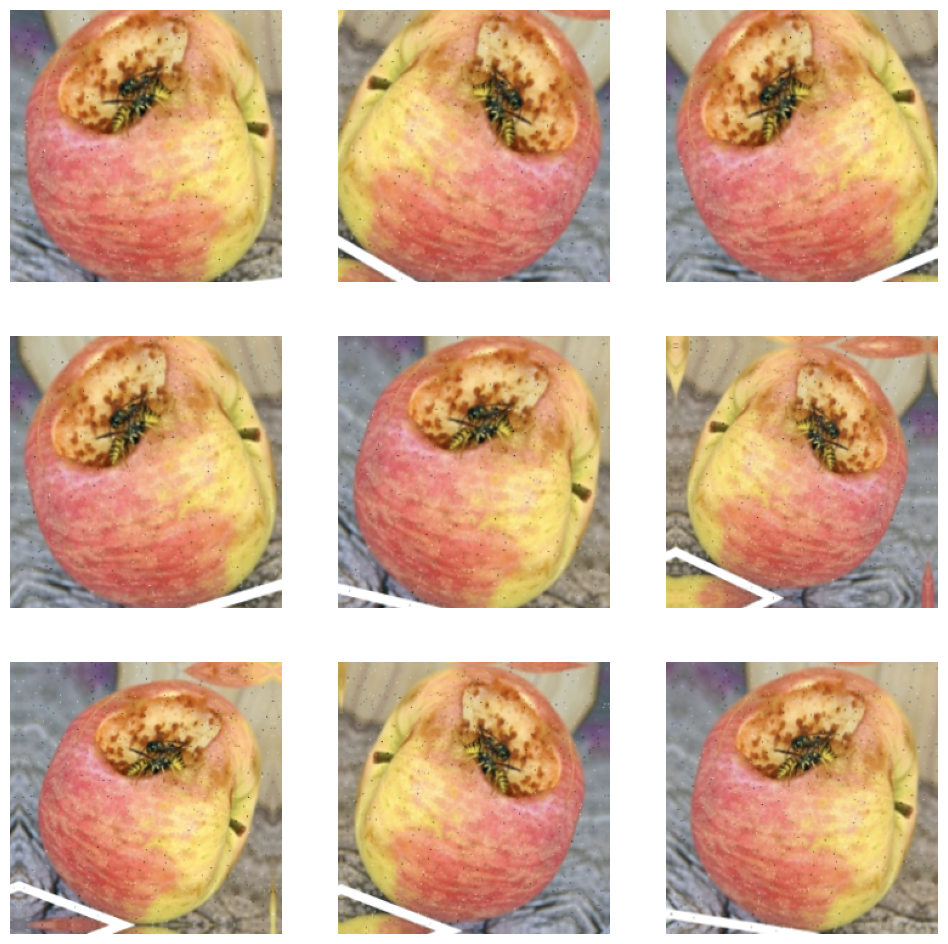

In [17]:
plt.figure(figsize=(12,12))

for images, labels in train_ds.take(1):

    first_image = images[0]

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        augmented = data_augmentation(
            tf.expand_dims(first_image,0)
        )

        plt.imshow(
            augmented[0].numpy().astype("uint8")
        )

        plt.axis("off")

plt.show()

In [18]:
normalization = layers.Lambda(preprocess_input)

In [19]:
for images, labels in train_ds.take(1):

    print("Image Batch Shape :", images.shape)

    print("Label Batch Shape :", labels.shape)

Image Batch Shape : (32, 224, 224, 3)
Label Batch Shape : (32, 6)


In [20]:
label_mapping = {
    i:name
    for i,name in enumerate(class_names)
}

print(label_mapping)

{0: 'freshapples', 1: 'freshbanana', 2: 'freshoranges', 3: 'rottenapples', 4: 'rottenbanana', 5: 'rottenoranges'}


In [21]:
import shutil

WORKING_DATASET = "/kaggle/working/freshness_dataset"

TRAIN_BINARY = os.path.join(WORKING_DATASET, "train")
TEST_BINARY = os.path.join(WORKING_DATASET, "test")

os.makedirs(TRAIN_BINARY, exist_ok=True)
os.makedirs(TEST_BINARY, exist_ok=True)

os.makedirs(os.path.join(TRAIN_BINARY, "Fresh"), exist_ok=True)
os.makedirs(os.path.join(TRAIN_BINARY, "Rotten"), exist_ok=True)

os.makedirs(os.path.join(TEST_BINARY, "Fresh"), exist_ok=True)
os.makedirs(os.path.join(TEST_BINARY, "Rotten"), exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


In [22]:
for folder in os.listdir(TRAIN_DIR):

    source = os.path.join(TRAIN_DIR, folder)

    if folder.startswith("fresh"):
        destination = os.path.join(TRAIN_BINARY, "Fresh")

    elif folder.startswith("rotten"):
        destination = os.path.join(TRAIN_BINARY, "Rotten")

    else:
        continue

    for image in os.listdir(source):

        shutil.copy2(
            os.path.join(source, image),
            os.path.join(destination, image)
        )

print("Training images merged.")

Training images merged.


In [23]:
for folder in os.listdir(TEST_DIR):

    source = os.path.join(TEST_DIR, folder)

    if folder.startswith("fresh"):
        destination = os.path.join(TEST_BINARY, "Fresh")

    elif folder.startswith("rotten"):
        destination = os.path.join(TEST_BINARY, "Rotten")

    else:
        continue

    for image in os.listdir(source):

        shutil.copy2(
            os.path.join(source, image),
            os.path.join(destination, image)
        )

print("Test images merged.")

Test images merged.


In [24]:
print("Training")

for folder in sorted(os.listdir(TRAIN_BINARY)):

    count = len(os.listdir(os.path.join(TRAIN_BINARY, folder)))

    print(folder, count)

print()

print("Testing")

for folder in sorted(os.listdir(TEST_BINARY)):

    count = len(os.listdir(os.path.join(TEST_BINARY, folder)))

    print(folder, count)

Training
Fresh 4740
Rotten 6161

Testing
Fresh 1164
Rotten 1534


In [25]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_BINARY,
    labels="inferred",
    label_mode="binary",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_BINARY,
    labels="inferred",
    label_mode="binary",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 10901 files belonging to 2 classes.
Found 2698 files belonging to 2 classes.


In [26]:
print(train_ds.class_names)

['Fresh', 'Rotten']


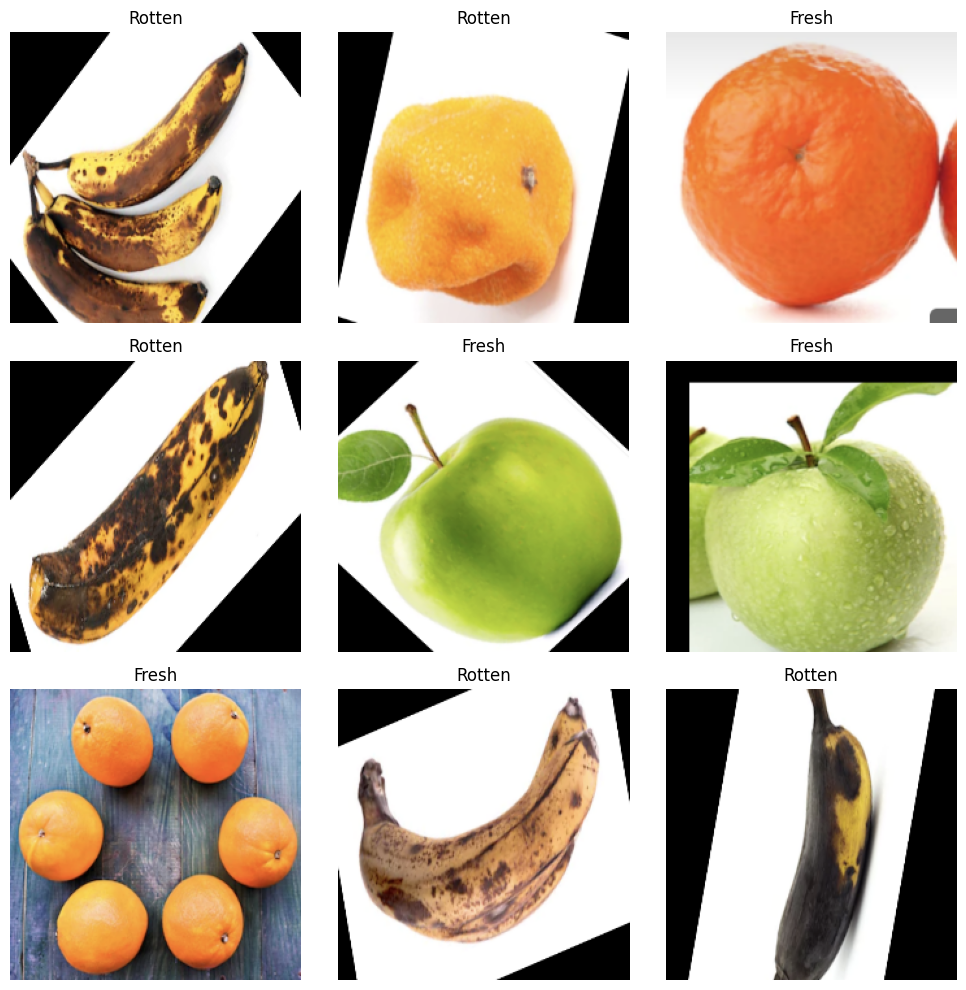

In [27]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        label = "Fresh" if labels[i].numpy() == 0 else "Rotten"

        plt.title(label)

        plt.axis("off")

plt.tight_layout()

plt.show()

In [28]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

In [29]:
train_ds = train_ds.cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)

test_ds = test_ds.cache().prefetch(tf.data.AUTOTUNE)

In [30]:
base_model = EfficientNetB0(

    include_top=False,

    weights="imagenet",

    input_shape=(224,224,3)

)

base_model.trainable = False

print("EfficientNetB0 Loaded")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB0 Loaded


In [31]:
inputs = tf.keras.Input(shape=(224,224,3))

x = data_augmentation(inputs)

x = preprocess_input(x)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.40)(x)

x = layers.Dense(

    256,

    activation="relu"

)(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.30)(x)

outputs = layers.Dense(

    1,

    activation="sigmoid"

)(x)

model = Model(

    inputs,

    outputs

)

In [32]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,383,908 (16.72 MB)

 Trainable params: 331,265 (1.26 MB)

 Non-trainable params: 4,052,643 (15.46 MB)

In [33]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=1e-3

    ),

    loss="binary_crossentropy",

    metrics=[

        "accuracy",

        tf.keras.metrics.Precision(),

        tf.keras.metrics.Recall(),

        tf.keras.metrics.AUC()

    ]

)

In [34]:
checkpoint = ModelCheckpoint(

    "/kaggle/working/best_freshness_model.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1

)

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True,

    verbose=1

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=2,

    min_lr=1e-6,

    verbose=1

)

In [35]:
history = model.fit(

    train_ds,

    validation_data=test_ds,

    epochs=15,

    callbacks=[

        checkpoint,

        early_stop,

        reduce_lr

    ]

)

Epoch 1/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9247 - auc: 0.9774 - loss: 0.1735 - precision: 0.9492 - recall: 0.9165
Epoch 1: val_accuracy improved from None to 0.98962, saving model to /kaggle/working/best_freshness_model.keras

Epoch 1: finished saving model to /kaggle/working/best_freshness_model.keras
341/341 ━━━━━━━━━━━━━━━━━━━━ 670s 2s/step - accuracy: 0.9584 - auc: 0.9923 - loss: 0.1070 - precision: 0.9697 - recall: 0.9563 - val_accuracy: 0.9896 - val_auc: 0.9994 - val_loss: 0.0309 - val_precision: 0.9896 - val_recall: 0.9922 - learning_rate: 0.0010
Epoch 2/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9775 - auc: 0.9973 - loss: 0.0626 - precision: 0.9801 - recall: 0.9799
Epoch 2: val_accuracy improved from 0.98962 to 0.99370, saving model to /kaggle/working/best_freshness_model.keras

Epoch 2: finished saving model to /kaggle/working/best_freshness_model.keras
341/341 ━━━━━━━━━━━━━━━━━━━━ 630s 2s/step - accuracy: 0.9790 - auc: 0.9977 - loss: 0.0567

In [36]:
base_model.trainable = True

In [37]:
fine_tune_at = len(base_model.layers)-30

for layer in base_model.layers[:fine_tune_at]:

    layer.trainable = False

print("Fine Tuning Started")

Fine Tuning Started


In [38]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=1e-5

    ),

    loss="binary_crossentropy",

    metrics=[

        "accuracy",

        tf.keras.metrics.Precision(),

        tf.keras.metrics.Recall(),

        tf.keras.metrics.AUC()

    ]

)

In [39]:
fine_history = model.fit(

    train_ds,

    validation_data=test_ds,

    epochs=10,

    callbacks=[

        checkpoint,

        early_stop,

        reduce_lr

    ]

)

Epoch 1/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9607 - auc_1: 0.9907 - loss: 0.1195 - precision_1: 0.9548 - recall_1: 0.9774
Epoch 1: val_accuracy did not improve from 0.99889
341/341 ━━━━━━━━━━━━━━━━━━━━ 709s 2s/step - accuracy: 0.9670 - auc_1: 0.9934 - loss: 0.0965 - precision_1: 0.9615 - recall_1: 0.9808 - val_accuracy: 0.9956 - val_auc_1: 1.0000 - val_loss: 0.0085 - val_precision_1: 0.9935 - val_recall_1: 0.9987 - learning_rate: 1.0000e-05
Epoch 2/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9808 - auc_1: 0.9966 - loss: 0.0571 - precision_1: 0.9807 - recall_1: 0.9855
Epoch 2: val_accuracy did not improve from 0.99889

Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
341/341 ━━━━━━━━━━━━━━━━━━━━ 729s 2s/step - accuracy: 0.9790 - auc_1: 0.9968 - loss: 0.0597 - precision_1: 0.9793 - recall_1: 0.9836 - val_accuracy: 0.9963 - val_auc_1: 1.0000 - val_loss: 0.0071 - val_precision_1: 0.9948 - val_recall_1: 0.9987 - learning_rate: 1.0

In [40]:
model.save(

    "/kaggle/working/freshness_model.keras"

)

print("Model Saved")

Model Saved


In [41]:
accuracy = history.history["accuracy"] + fine_history.history["accuracy"]

val_accuracy = history.history["val_accuracy"] + fine_history.history["val_accuracy"]

loss = history.history["loss"] + fine_history.history["loss"]

val_loss = history.history["val_loss"] + fine_history.history["val_loss"]

epochs = range(1,len(accuracy)+1)

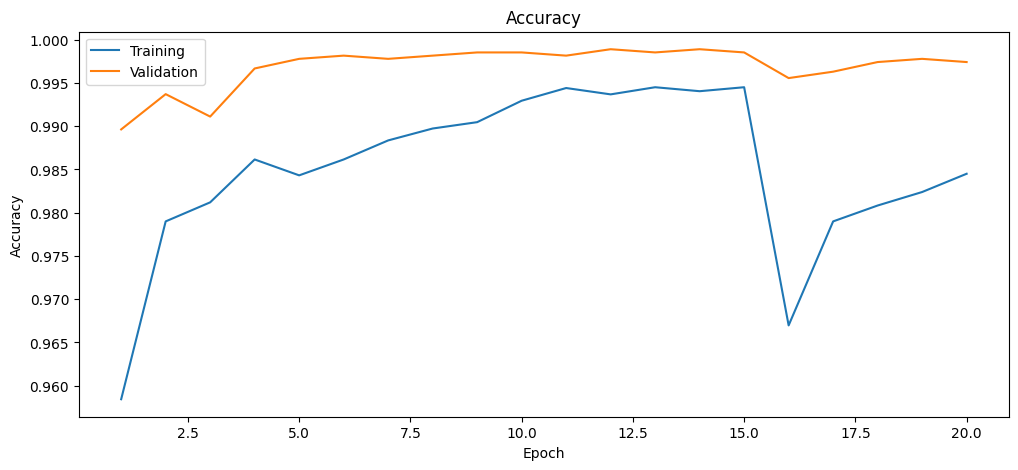

In [42]:
plt.figure(figsize=(12,5))

plt.plot(

    epochs,

    accuracy,

    label="Training"

)

plt.plot(

    epochs,

    val_accuracy,

    label="Validation"

)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Accuracy")

plt.legend()

plt.show()

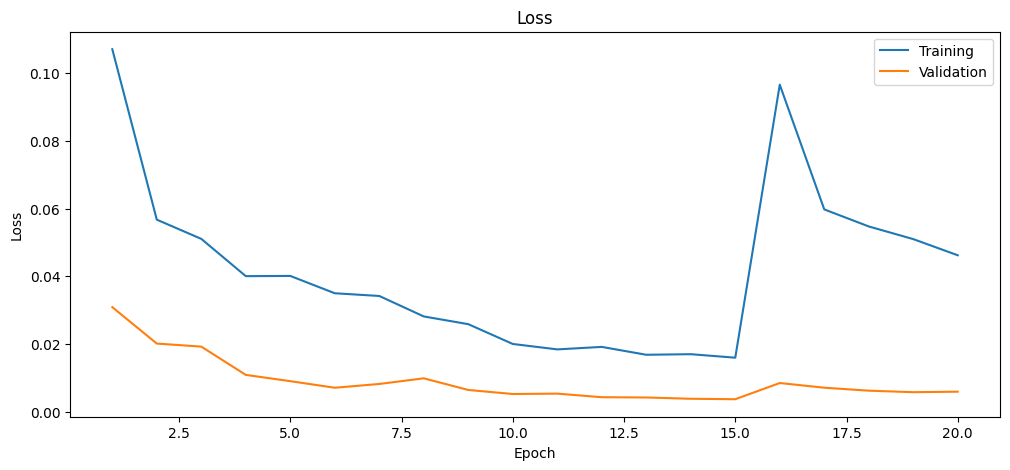

In [43]:
plt.figure(figsize=(12,5))

plt.plot(

    epochs,

    loss,

    label="Training"

)

plt.plot(

    epochs,

    val_loss,

    label="Validation"

)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss")

plt.legend()

plt.show()

In [44]:
import json
import pickle

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

In [45]:
results = model.evaluate(
    test_ds,
    verbose=1
)

metric_names = model.metrics_names

print("="*50)

for name, value in zip(metric_names, results):
    print(f"{name:<15}: {value:.4f}")

print("="*50)

85/85 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.9956 - auc_1: 1.0000 - loss: 0.0085 - precision_1: 0.9935 - recall_1: 0.9987
loss           : 0.0085
compile_metrics: 0.9956


In [46]:
y_true = []
y_pred_prob = []

for images, labels in test_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    y_pred_prob.extend(predictions.flatten())

    y_true.extend(labels.numpy().flatten())

y_true = np.array(y_true)

y_pred_prob = np.array(y_pred_prob)

y_pred = (y_pred_prob >= 0.5).astype(int)

In [47]:
print(

    classification_report(

        y_true,

        y_pred,

        target_names=["Fresh","Rotten"]

    )

)

              precision    recall  f1-score   support

       Fresh       1.00      0.99      0.99      1164
      Rotten       0.99      1.00      1.00      1534

    accuracy                           1.00      2698
   macro avg       1.00      1.00      1.00      2698
weighted avg       1.00      1.00      1.00      2698



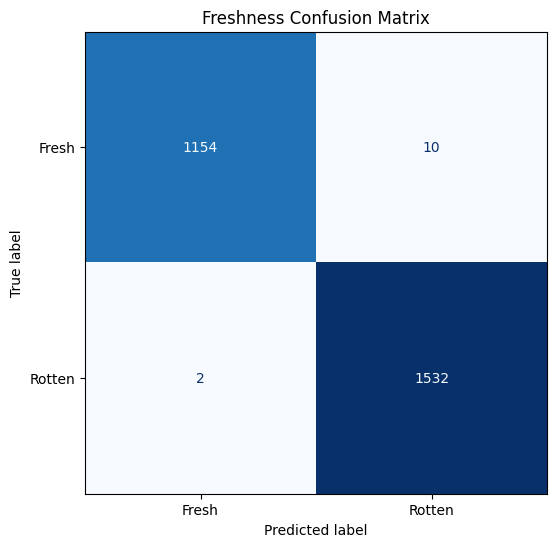

In [48]:
cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fresh","Rotten"]
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Freshness Confusion Matrix")

plt.show()

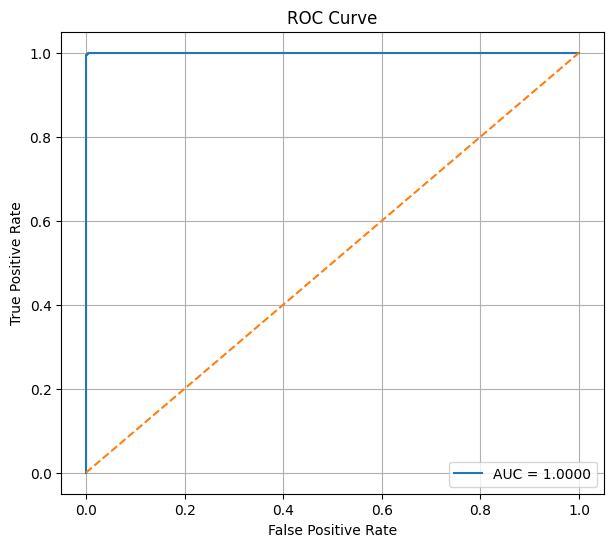

In [49]:
fpr, tpr, thresholds = roc_curve(
    y_true,
    y_pred_prob
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid()

plt.show()

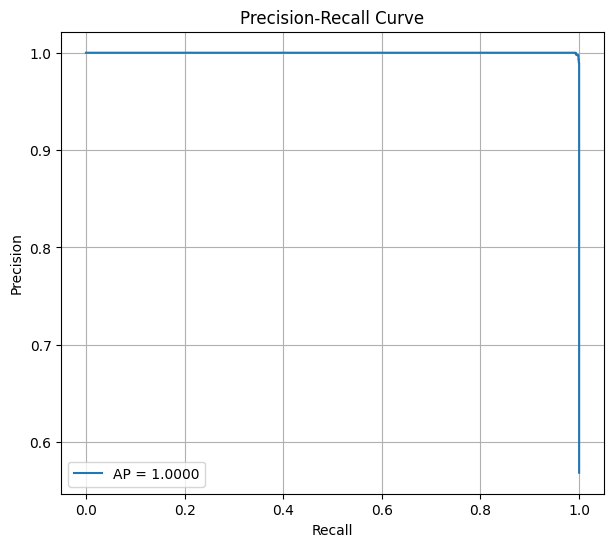

In [50]:
precision, recall, _ = precision_recall_curve(
    y_true,
    y_pred_prob
)

ap = average_precision_score(
    y_true,
    y_pred_prob
)

plt.figure(figsize=(7,6))

plt.plot(
    recall,
    precision,
    label=f"AP = {ap:.4f}"
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.grid()

plt.show()

In [51]:
label_mapping = {

    0:"Fresh",

    1:"Rotten"

}

with open(

    "/kaggle/working/freshness_labels.json",

    "w"

) as f:

    json.dump(

        label_mapping,

        f,

        indent=4

    )

print(label_mapping)

{0: 'Fresh', 1: 'Rotten'}


In [52]:
from tensorflow.keras.preprocessing import image

def predict_freshness(image_path):

    img = image.load_img(

        image_path,

        target_size=(224,224)

    )

    img_array = image.img_to_array(img)

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    img_array = preprocess_input(
        img_array
    )

    prediction = model.predict(
        img_array,
        verbose=0
    )[0][0]

    fresh_probability = 1 - prediction

    rotten_probability = prediction

    if prediction < 0.5:

        freshness = "Fresh"

        confidence = fresh_probability

    else:

        freshness = "Rotten"

        confidence = rotten_probability

    return {

        "freshness": freshness,

        "confidence": float(confidence),

        "fresh_probability": float(fresh_probability),

        "rotten_probability": float(rotten_probability)

    }

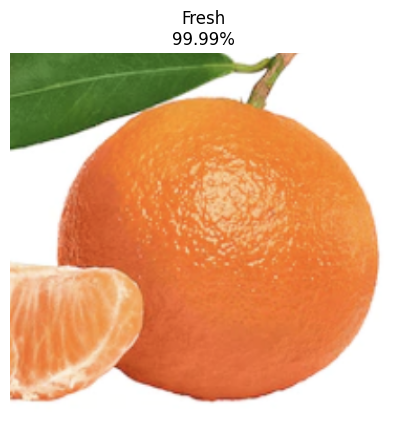

{'freshness': 'Fresh', 'confidence': 0.9998917579650879, 'fresh_probability': 0.9998917579650879, 'rotten_probability': 0.00010824488708749413}


In [53]:
sample_folder = random.choice(
    ["Fresh","Rotten"]
)

sample_image = random.choice(

    os.listdir(

        os.path.join(
            TEST_BINARY,
            sample_folder
        )

    )

)

sample_path = os.path.join(

    TEST_BINARY,

    sample_folder,

    sample_image

)

result = predict_freshness(
    sample_path
)

img = plt.imread(sample_path)

plt.figure(figsize=(5,5))

plt.imshow(img)

plt.axis("off")

plt.title(

    f"{result['freshness']}\n"

    f"{result['confidence']:.2%}"

)

plt.show()

print(result)

In [54]:
def predict_folder(folder):

    results = []

    for img in os.listdir(folder):

        path = os.path.join(folder,img)

        prediction = predict_freshness(path)

        prediction["image"] = img

        results.append(prediction)

    return results

In [55]:
history_data = {

    "accuracy": accuracy,

    "val_accuracy": val_accuracy,

    "loss": loss,

    "val_loss": val_loss

}

with open(

    "/kaggle/working/freshness_history.pkl",

    "wb"

) as f:

    pickle.dump(

        history_data,

        f

    )

print("Training history saved.")

Training history saved.


In [56]:
model.save(
    "/kaggle/working/freshness_model.keras"
)

print("Freshness model saved.")

Freshness model saved.
